# Correlation and Variable Relationships

## Introduction

> ❓ **How do you go from "it looks like a positive relationship" to a rigorous,
> reproducible scientific statement?**
>
> Visualization (Lesson 2) told us that larger properties tend to cost more. But
> "tends to" is not science. A correlation coefficient is. This lesson teaches you
> the mathematical foundation of correlation, how to compute and visualize it
> across all variable pairs simultaneously, and — critically — why the national
> average conceals radically different local stories.

In Lesson 2, we saw three things visually:
- The price distribution is right-skewed.
- There is a positive relationship between area and price, but with significant scatter.
- The strength of that relationship varies by state.

This lesson quantifies all three observations. We measure the strength of the
area-price relationship precisely, visualize all pairwise relationships in a
heatmap, and discover that the national correlation is a misleading average — the
relationship is much stronger in some states than others.

**Research Question:** Is the size of a property (`area_m2`) a stronger predictor
of price than its location?

By the end of this lesson we will have computed the evidence needed to give a
qualified, data-driven answer.

## 1. Setup and Data Loading

We import our libraries and load the clean dataset. This lesson introduces
`seaborn` (aliased as `sns`), a statistical visualization library that makes
heatmaps effortless.

**Code Task 1.3.1.1**: Import `pandas`, `matplotlib.pyplot`, and `seaborn`,
define `data_path`, and load the data.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Define the path to the clean CSV file
data_path = 'data/mexico-real-estate-combined-clean.csv'

# Load the data
data = pd.read_csv(data_path,encoding='latin')
# Verify the load
print(f"Dimensions: {data.shape[0]} rows and {data.shape[1]} columns.")
data.head()

Dimensions: 1736 rows and 6 columns.


,property_type,state,lat,lon,area_m2,price_usd
0,house,Estado de MÃ©xico,19.560181,-99.233528,150.0,67965.56
1,house,Nuevo LeÃ³n,25.688436,-100.198807,186.0,63223.78
2,apartment,Guerrero,16.767704,-99.764383,82.0,84298.37
3,apartment,Guerrero,16.829782,-99.911012,150.0,94308.80
4,house,YucatÃ¡n,21.052583,-89.538639,205.0,105191.37


## 2. The Pearson Correlation Coefficient

> ❓ **If I show you two scatter plots — one with a tight cluster around a rising
> line, one with a diffuse cloud that slopes upward — which relationship is
> "stronger"? How would you put a number on it?**

The Pearson correlation coefficient answers exactly this question. It converts the
visual impression of a scatter plot into a single number between -1 and 1.

### 2.1 Intuition

Imagine you are measuring whether people who drink more coffee also sleep less.
For each person, you have two numbers: cups of coffee per day (X) and hours of
sleep (Y). You want to know: when X is above its average, does Y tend to be below
its average (negative relationship)? Or do above-average X and above-average Y
tend to go together (positive relationship)?

The Pearson coefficient formalizes this intuition:

- For each data point, compute how far X is from its mean (`x - x_mean`) and how
  far Y is from its mean (`y - y_mean`).
- Multiply these two deviations together. If both are above-average (both positive),
  the product is positive. If both are below-average (both negative), the product
  is still positive. If one is above and one is below, the product is negative.
- Sum all these products. Divide by the total variability to keep the result
  between -1 and +1.

### 2.2 The Math

$$r_{XY} = \frac{\sum_{i=1}^{n}(x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum(x_i - \bar{x})^2}\,\sqrt{\sum(y_i - \bar{y})^2}}$$

**Numerator** — $\sum(x_i - \bar{x})(y_i - \bar{y})$:

For each observation $i$, the product $(x_i - \bar{x})(y_i - \bar{y})$ is:

- **Positive** when both X and Y are simultaneously above their averages, OR both
  below their averages (they move together).
- **Negative** when X is above its average while Y is below (they move in opposite
  directions).

Summing across all observations gives a measure of the *overall tendency* to move
together.

**Denominator** — the scaling factor:

$$\sqrt{\sum(x_i - \bar{x})^2} \cdot \sqrt{\sum(y_i - \bar{y})^2}$$

This is the product of the standard deviations (without the $\frac{1}{n-1}$ factor)
of X and Y. Dividing by it *normalizes* the numerator, ensuring $r$ always falls
between -1 and +1 regardless of the units or scale of X and Y.

> 📌 **Interpretation bands**
>
> | Value | Interpretation |
> |---|---|
> | `r = 1.0` | Perfect positive linear relationship |
> | `0.7 ≤ r < 1.0` | Strong positive relationship |
> | `0.4 ≤ r < 0.7` | Moderate positive relationship |
> | `0.1 ≤ r < 0.4` | Weak positive relationship |
> | `-0.1 < r < 0.1` | No meaningful linear relationship |
> | `-0.4 < r ≤ -0.1` | Weak negative relationship |
> | `-0.7 < r ≤ -0.4` | Moderate negative relationship |
> | `r = -1.0` | Perfect negative linear relationship |
>
> These bands are conventions, not laws. Context matters: an r = 0.35 for a
> psychological phenomenon with 10,000 confounders is impressive; r = 0.35 for
> predicting weight from height is weak.

### 2.3 Three Critical Caveats

> ⚠️ **Pearson r measures only LINEAR relationships.**
>
> A strong curved relationship (e.g., price per m² *decreases* as area increases)
> can produce a low Pearson r — not because there is no relationship, but because
> the relationship is not linear. In §5 we will see this directly: `area_m2` and
> `price_per_m2` have a clear curved pattern that Pearson r understates.

> ⚠️ **r does not imply causation.**
>
> "Area and price are correlated" means they move together. It does not mean area
> *causes* the price. Both could be driven by a third variable (location, property
> type) that makes large properties cluster in expensive areas.

> ⚠️ **r is sensitive to outliers and sample size.**
>
> A single extreme data point can dramatically change r. A correlation of r = 0.95
> based on 5 observations is nearly meaningless — five points almost always fit a
> line perfectly by chance. The same r based on 500 observations is meaningful.
> We will see this directly when we compute segmented correlations by state: states
> with very few listings show extreme r values (near -1 or +1) that are artifacts
> of small samples, not real patterns.

### 2.4 Computing Correlation in pandas

Pandas provides two ways to compute Pearson correlation:

| Method | Returns | Use when |
|---|---|---|
| `series_a.corr(series_b)` | A single float | You want the correlation between two specific columns |
| `df.corr()` | A DataFrame (correlation matrix) | You want all pairwise correlations at once |

By default, `.corr()` uses Pearson's method. You can specify alternatives:
`method='kendall'` (rank-based, robust to outliers) or `method='spearman'` (rank
correlation). For this project we use the default Pearson.

---

✅ You can take **Multiple Choice Question 1.3.2.1**

---

### 2.5 Calculating the National Area-Price Correlation

**Code Task 1.3.2.1**: Compute the Pearson correlation between `"area_m2"` and
`"price_usd"` for the full national dataset.

---

✅ You can take **Multiple Choice Question 1.3.2.2**

---


In [2]:
# Calculate correlation between 'area_m2' and 'price_usd'
corr_price_area = (
    data['area_m2']
    .corr(data['price_usd'])
)

print(f"The correlation between Area and Price is: {corr_price_area:.4f}")

The correlation between Area and Price is: 0.5855


> 📊 **What r ≈ 0.59 means — precisely, practically, and what it leaves unanswered**

**What it means precisely:**

The Pearson r of approximately 0.59 between `area_m2` and `price_usd` tells us
that roughly **35% of the variance in price can be "explained" by area** (because
r² = 0.59² ≈ 0.35). In plain language: if you know nothing about a property except
its size, knowing the area reduces your uncertainty about the price by about 35%.
The remaining 65% of price variation is explained by other factors — location,
property type, condition, amenities, and factors we have not measured.

**What it implies for prediction accuracy:**

If you were to build the simplest possible predictive model — a straight line
through the cleaned scatterplot — that model would have substantial predictive
power but large individual errors. Concretely:

- The model would correctly rank properties by price in about 70% of pairwise
  comparisons (this is related to a statistic called the concordance index).
- But for any individual property, the prediction interval would be very wide —
  perhaps ±40,000 around the predicted value. Knowing a property is 120 m²
  tells you the predicted price is around 102,000, but the true price could
  easily be anywhere from 60,000 to 180,000.
- This wide prediction interval is not a failure of the model — it is an accurate
  statement about how much unexplained variation exists. Area is a useful but
  incomplete predictor of price.

**What r = 0.59 does not answer:**

- **Is the relationship the same everywhere?** A national r of 0.59 is a weighted
  average of all state-level relationships. Some states may have r ≈ 0.85 (size
  strongly predicts price), while others have r ≈ 0.10 (size barely matters). The
  national number conceals this variation entirely. Section 4 will reveal it.

- **Is the relationship causal?** Correlation is not causation. The fact that
  larger properties cost more does not mean that *adding square footage causes a
  property to become more valuable*. Both area and price may be driven by the same
  underlying variable — location. In an expensive neighborhood, both larger
  properties and higher prices are the norm; in a cheap neighborhood, both smaller
  properties and lower prices are the norm. The correlation may partly reflect
  location sorting rather than a pure size effect.

- **Is the relationship linear?** Pearson r assumes linearity. If the true
  relationship is curved — for example, if each additional square meter becomes
  *less* valuable as total size grows (diminishing returns) — then r will
  understate the true relationship. Section 5 will test this with the
  `price_per_m2` feature.


> 📊 **Reading the national correlation result**
>
> A result around **r ≈ 0.59** falls in the "moderate-to-strong positive" band.
>
> **What this means in plain language:** When a property has above-average area,
> it also tends to have an above-average price — and vice versa. This confirms the
> visual pattern from the scatter plots in Lesson 2. But it also confirms the
> *noise*: the scatter around the trend line was wide, which is consistent with an
> r of 0.59 rather than 0.9+.
>
> **What 0.59 cannot tell you:**
> - Whether the relationship is the same everywhere in Mexico (it is not — §4 will show this).
> - Whether the relationship is truly linear (§5 will challenge this with the
>   price-per-m² analysis).
> - Whether location matters more or less than size (the research question — we
>   will combine evidence from §4 and Lesson 4 to answer this).
>
> ➡️ **A single national r is only the starting point.** Real insight requires
> looking at the matrix of all pairwise correlations and then breaking the data
> apart by group.

## 3. The Correlation Matrix and Heatmaps

Often, we want to check the relationships between *all* numerical variables at
once — not just area vs price. A **correlation matrix** is a square table
containing the Pearson r for every pair of variables.

For a dataset with $n$ numeric columns, the matrix has $n 	imes n$ entries. The
diagonal is always 1.0 (a variable is perfectly correlated with itself). The matrix
is symmetric ($r_{AB} = r_{BA}$), so you only need to read one triangle.

**When to use a correlation matrix — and when not to:**

A correlation matrix is most useful in the early exploratory phase of an analysis,
when you have multiple numeric variables and want to quickly identify which pairs
are worth investigating further. In our housing dataset, we have `area_m2`,
`price_usd`, `lat`, and `lon` — four numeric variables, giving a 4×4 matrix with
six unique pairwise correlations (excluding the trivial diagonal). Computing these
six numbers individually would be tedious; the matrix computes them all at once.

**Use a correlation matrix when:**
- You have 3 or more numerical variables and want a systematic overview.
- You are looking for variable pairs to include in a regression model (highly
  correlated predictors signal multicollinearity — a problem to avoid).
- You are doing feature selection for a machine learning model — strongly
  correlated variables with the target are candidate predictors; strongly
  correlated variables with each other are redundant.
- You want to validate domain knowledge: "I expect price and area to be
  positively correlated — does the data confirm this?"

**Do not rely on a correlation matrix when:**
- Your relationships are non-linear. A strong curved relationship between two
  variables can produce a low Pearson r. The matrix would mislead you into
  thinking the variables are unrelated.
- You have categorical variables. Pearson r requires numeric data. To include
  categorical variables in a correlation-like analysis, you would need different
  statistics (point-biserial correlation, Cramér's V, etc.).
- Your goal is causal inference rather than description. Correlation matrices
  show associations, not causation. Two variables can be strongly correlated
  because of a shared cause, not because one causes the other.

### 3.1 Computing the Matrix

**Code Task 1.3.3.1**: Compute the full correlation matrix.


In [3]:
# Select only numerical columns
# Compute the correlation matrix
corr_matrix = (
    data
    .select_dtypes("number") # to select the numeric data only
    .corr()
)

corr_matrix

,lat,lon,area_m2,price_usd
lat,1.000000,-0.480231,0.082314,-0.085868
lon,-0.480231,1.000000,0.095522,0.032815
area_m2,0.082314,0.095522,1.000000,0.585518
price_usd,-0.085868,0.032815,0.585518,1.000000


### 3.2 Visualizing with a Heatmap

A table of numbers is hard to scan. A **heatmap** encodes the correlation values
as colors — making patterns immediately visible to the eye.

> 💡 **Why heatmaps work for correlation matrices**
>
> The human visual system is excellent at detecting color intensity differences.
> A heatmap of a 6×6 matrix takes under one second to interpret — you immediately
> see which pairs are strongly correlated (dark red/dark blue) and which are
> uncorrelated (white/near-white). A table of 36 numbers takes much longer.

`seaborn.heatmap()` parameters worth knowing:

| Parameter | What it does | Our choice |
|---|---|---|
| `annot=True` | Prints the numeric r value inside each cell | Keeps precision alongside the color |
| `cmap="coolwarm"` | Red = positive, Blue = negative, White = zero | Intuitive: hot = positive |
| `ax=ax` | Draws on our explicit Matplotlib Axes | Integrates with the explicit interface |
| `vmin=-1, vmax=1` | Pins the color scale to [-1, +1] | Optional but good practice |

**Code 1.3.3.1** — Heatmap:


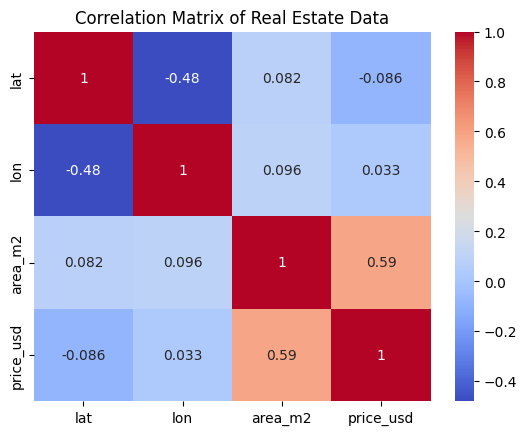

In [4]:
# Create a figure
fig, ax = plt.subplots()

# Create the heatmap using Seaborn
# annot=True adds the numbers to the boxes
# cmap="coolwarm" creates a nice Red (hot/positive) to Blue (cold/negative) spectrum
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", ax=ax)

ax.set_title("Correlation Matrix of Real Estate Data")
plt.show()

> 📊 **Reading the correlation heatmap**
>
> Scan the `price_usd` row (or column) — this shows how strongly each other
> variable correlates with price.
>
> **Key findings:**
>
> - **`area_m2` ↔ `price_usd` ≈ 0.59** — the moderate-to-strong relationship we
>   computed directly above. The cell should be a moderately warm red.
> - **`lat` ↔ `price_usd`** and **`lon` ↔ `price_usd`** — weaker correlations.
>   Geographic coordinates and price are loosely related, but coordinates are
>   coarse proxies for location.
> - **The diagonal** — always 1.0 (deep red), because every variable is perfectly
>   correlated with itself.
> - **`lat` ↔ `lon` ≈ -0.48** — a moderately strong negative correlation that
>   has nothing to do with real estate.
>
> **Why is the lat-lon correlation -0.48?**
>
> This is a **geographical artifact**: Mexico is not a rectangular country. It
> narrows and tilts as you move north (toward higher latitude). The northernmost
> states (Baja California, Chihuahua) cluster at specific longitudes, while the
> southern states (Oaxaca, Chiapas) cluster at different longitudes. Moving north
> (increasing latitude) shifts which longitudes are represented — creating an
> apparent negative correlation. This tells us nothing about property prices.
>
> > ⚠️ **Not every number in a correlation matrix is actionable.** The lat-lon
> > correlation is real (it exists in the data) but it is a geometric fact about
> > Mexico's shape, not a market signal. Always ask: *"Does this correlation make
> > real-world sense, or is something structural creating a spurious pattern?"*
>
> **The Simpson's Paradox warning:**
>
> A global correlation coefficient is an average across all subgroups. If the
> size-price relationship differs dramatically by state (which §4 will confirm),
> then the national r = 0.59 is a weighted average of very different local
> relationships. It may not describe *any* individual state accurately. This is
> the central warning of **Simpson's Paradox**: an aggregate statistic can
> actively mislead you about subgroup behavior.

**How to read a correlation heatmap systematically — a checklist:**

A heatmap packs a lot of information into a small space. Use this checklist to
ensure you extract all of it without missing important patterns:

- **Step 1 — Orient yourself.** Identify the row and column labels. In a 4×4
  matrix of `area_m2`, `price_usd`, `lat`, `lon`, each row and column header
  names one variable. The cell at row i, column j shows the correlation between
  variable i and variable j.

- **Step 2 — Verify the diagonal.** Every cell on the main diagonal (top-left to
  bottom-right) should show 1.00 in deep red (or the highest-intensity color in
  your colormap). This is a built-in sanity check: a variable is always perfectly
  correlated with itself. If any diagonal cell is not 1.00, something is wrong
  with your computation.

- **Step 3 — Identify the strongest off-diagonal correlations.** Scan for the
  deepest colors — both positive (deep red/warm) and negative (deep blue/cool).
  These are the strongest pairwise relationships. In our heatmap, the
  `area_m2`–`price_usd` cell should be the warmest off-diagonal cell, confirming
  that size-price is the dominant relationship in the dataset.

- **Step 4 — Check the annotated numbers.** The color gives a visual impression;
  the number inside the cell gives precision. An r of 0.55 and an r of 0.65 might
  look similar in color but have meaningfully different practical implications.
  Always read the numbers, not just the colors.

- **Step 5 — Look for unexpected strong correlations.** The `lat`–`lon`
  correlation of approximately -0.48 is an example: it is strong enough to be
  visually noticeable but is entirely a geographic artifact (Mexico's shape), not
  a market signal. Unexpected strong correlations always deserve investigation.
  Ask: "Does this make real-world sense? Or is something structural creating a
  spurious pattern?"

- **Step 6 — Note near-zero correlations.** Cells near white (close to zero) are
  pairs where the two variables have no meaningful linear association. For our
  dataset, `lat` and `price_usd` may be near-zero, suggesting that raw latitude
  (how far north the property is) does not linearly predict price — even though
  we know from the boxplots that location matters. This apparent contradiction
  reveals a limitation of linear correlation: the relationship between latitude
  and price may be non-linear or category-dependent (controlled by which state
  the property is in, not the raw coordinate).

---

✅ You can take **Multiple Choice Question 1.3.4.1**

---

## 4. Segmented Correlations: Why Averages Lie

The national r = 0.59 is our starting point — not our conclusion. The next
question is: **is this relationship consistent across all states, or does it
vary dramatically?**

If it varies, then the national number is a fiction — an average of very different
local markets. This matters for our research question: if size is a strong
predictor in rural states but weak in urban ones, then the true answer to "does
size predict price?" depends entirely on *which state* you are asking about.


In [5]:
(
    data
    .head()
)

,property_type,state,lat,lon,area_m2,price_usd
0,house,Estado de MÃ©xico,19.560181,-99.233528,150.0,67965.56
1,house,Nuevo LeÃ³n,25.688436,-100.198807,186.0,63223.78
2,apartment,Guerrero,16.767704,-99.764383,82.0,84298.37
3,apartment,Guerrero,16.829782,-99.911012,150.0,94308.80
4,house,YucatÃ¡n,21.052583,-89.538639,205.0,105191.37


### 4.1 Correlation by State — Step by Step

To compute per-state correlations, we need to:
1. **Split** the data by state — so each group contains only the listings for one state.
2. **Apply** `.corr()` to each group — getting a 2×2 correlation matrix per state.
3. **Extract** the single number we care about (the area-price correlation, not the
   trivial 1.0 diagonal).
4. **Combine** the results into a ranked Series.

This is the **split-apply-combine** pattern from Lesson 2, extended to correlation.

We will build this chain step by step, running each intermediate result in its own
cell before assembling the full pipeline. This is the recommended way to build any
complex chain: build slowly, verify at each step, then collapse into one chain.

Before we can calculate correlations per state, we need to tell pandas two things:

- **How to group** — by `"state"` — so each group is one state's listings.
- **Which columns to include** — just `"area_m2"` and `"price_usd"`. Including
  `lat`, `lon`, and `property_type` would produce a larger matrix than we need.

**Code 1.3.4.2** — Group by state and select columns:

> Run this cell. You will NOT see actual data — pandas displays a
> `DataFrameGroupBy object`. This is intentional. The groupby object is like
> a recipe: it tells pandas *how* to split the data, but it does not split it
> yet. The actual computation happens when you chain the next method.
> Think of it as: "I have your groups organized and ready — what do you want
> to compute on them?"


In [6]:
(
    data
    .groupby("state")
    [["area_m2", "price_usd"]].corr()
)

area_m2  price_usd
state                                                         
Aguascalientes                  area_m2    1.000000   0.873437
                                price_usd  0.873437   1.000000
Baja California                 area_m2    1.000000   0.658334
                                price_usd  0.658334   1.000000
Baja California Sur             area_m2    1.000000   0.880583
                                price_usd  0.880583   1.000000
Campeche                        area_m2    1.000000   0.824161
                                price_usd  0.824161   1.000000
Chiapas                         area_m2    1.000000   0.755961
                                price_usd  0.755961   1.000000
Chihuahua                       area_m2    1.000000   0.636292
                                price_usd  0.636292   1.000000
Colima                          area_m2    1.000000   0.988235
                                price_usd  0.988235   1.000000
Distrito Federal                area_m2    1.000000   0.410704
                                price_usd  0.410704   1.000000
Durango                         area_m2    1.000000   0.909258
                                price_usd  0.909258   1.000000
Estado de MÃ©xico               area_m2    1.000000   0.630110
                                price_usd  0.630110   1.000000
Guanajuato                      area_m2    1.000000   0.601482
                                price_usd  0.601482   1.000000
Guerrero                        area_m2    1.000000   0.674457
                                price_usd  0.674457   1.000000
Hidalgo                         area_m2    1.000000   0.822157
                                price_usd  0.822157   1.000000
Jalisco                         area_m2    1.000000   0.612017
                                price_usd  0.612017   1.000000
Morelos                         area_m2    1.000000   0.849808
                                price_usd  0.849808   1.000000
Nayarit                         area_m2    1.000000   0.774295
                                price_usd  0.774295   1.000000
Nuevo LeÃ³n                     area_m2    1.000000   0.578696
                                price_usd  0.578696   1.000000
Oaxaca                          area_m2    1.000000  -1.000000
                                price_usd -1.000000   1.000000
Puebla                          area_m2    1.000000   0.772550
                                price_usd  0.772550   1.000000
QuerÃ©taro                      area_m2    1.000000   0.819374
                                price_usd  0.819374   1.000000
Quintana Roo                    area_m2    1.000000   0.626626
                                price_usd  0.626626   1.000000
San Luis PotosÃ­                area_m2    1.000000   0.855196
                                price_usd  0.855196   1.000000
Sinaloa                         area_m2    1.000000   0.625892
                                price_usd  0.625892   1.000000
Sonora                          area_m2    1.000000   0.911524
                                price_usd  0.911524   1.000000
Tabasco                         area_m2    1.000000   0.241284
                                price_usd  0.241284   1.000000
Tamaulipas                      area_m2    1.000000   0.763998
                                price_usd  0.763998   1.000000
Tlaxcala                        area_m2    1.000000   0.743335
                                price_usd  0.743335   1.000000
Veracruz de Ignacio de la Llave area_m2    1.000000   0.567469
                                price_usd  0.567469   1.000000
YucatÃ¡n                        area_m2    1.000000   0.740413
                                price_usd  0.740413   1.000000
Zacatecas                       area_m2    1.000000   1.000000
                                price_usd  1.000000   1.000000

**Code 1.3.4.3** — Apply `.corr()` to each group:

> Run this and study the output carefully. For every state, pandas produced a
> **2×2 correlation matrix**. The output has a **MultiIndex** — two levels of
> labels on the left:
>
> - **Outer level** (level 0): the state name (e.g., `"Aguascalientes"`)
> - **Inner level** (level 1): the variable name (`"area_m2"` or `"price_usd"`)
>
> Each 2×2 matrix has four cells:
> - `area_m2` vs `area_m2` = 1.0 (trivial — every variable correlates perfectly
>   with itself)
> - `area_m2` vs `price_usd` = the correlation we want
> - `price_usd` vs `area_m2` = same number (matrix is symmetric)
> - `price_usd` vs `price_usd` = 1.0 (trivial)
>
> We need to extract just one number per state — the `area_m2` ↔ `price_usd`
> correlation. The next two steps do this by navigating the MultiIndex.


In [7]:
(
    data
    .groupby("state")
    [["area_m2", "price_usd"]]
    .corr()
    .head() # <-- to only view the top 5 rows. 
)

area_m2  price_usd
state                                             
Aguascalientes      area_m2    1.000000   0.873437
                    price_usd  0.873437   1.000000
Baja California     area_m2    1.000000   0.658334
                    price_usd  0.658334   1.000000
Baja California Sur area_m2    1.000000   0.880583

**Code 1.3.4.4** — `.iloc[:, 1]` — select only the `price_usd` column:

> 📌 **`.iloc` explained**
>
> - `iloc` stands for **integer location** — selection by position number, not by
>   label name.
> - `.iloc[:, 1]` means: "from all rows (`:`), give me only the column at index
>   position 1."
>
> In our 2×2 matrix, columns are `area_m2` (position 0) and `price_usd` (position 1).
> Selecting position 1 keeps only the `price_usd` column, reducing from 4 values
> per state to 2 values per state.
>
> **After this step**, you still have 2 rows per state:
> - `area_m2` row: the area-price correlation (what we want)
> - `price_usd` row: always 1.0 (trivial, must be removed)
>
> The next step (`.xs()`) extracts only the `area_m2` row from each state.


In [8]:
(
    data
    .groupby("state")
    [["area_m2", "price_usd"]]
    .corr()
    .iloc[:, 1]
    .head(10) # <-- to only view the top 10 rows
)

state                         
Aguascalientes       area_m2      0.873437
                     price_usd    1.000000
Baja California      area_m2      0.658334
                     price_usd    1.000000
Baja California Sur  area_m2      0.880583
                     price_usd    1.000000
Campeche             area_m2      0.824161
                     price_usd    1.000000
Chiapas              area_m2      0.755961
                     price_usd    1.000000
Name: price_usd, dtype: float64

**Code 1.3.4.5** — `.xs("area_m2", level=1)` — extract one correlation per state:

> 📌 **`.xs()` — cross-section through a MultiIndex**
>
> `.xs()` lets you "slice through" a MultiIndex at a specific level and value.
>
> - `"area_m2"` is the label we want to keep.
> - `level=1` tells pandas to look at the **inner** level of the index (the variable
>   name level, not the state level which is at level 0).
>
> **After this step**, you have exactly one correlation value per state — the
> `area_m2` ↔ `price_usd` Pearson r for that state's listings.
>
> The MultiIndex is gone; the result is a simple Series indexed by state name.
>
> **Try it yourself:** Replace `"area_m2"` with `"price_usd"` in the `.xs()` call
> and re-run. You should get a Series of 1.0 values — because `price_usd`
> correlated with itself is always 1. This confirms that `"area_m2"` is the row
> we actually want.


In [9]:
(
    data
    .groupby("state")
    [["area_m2", "price_usd"]]
    .corr()
    .iloc[:, 1]
    .xs("area_m2", level=1)
    .head() # <-- to only view the top 5 rows
)

state
Aguascalientes         0.873437
Baja California        0.658334
Baja California Sur    0.880583
Campeche               0.824161
Chiapas                0.755961
Name: price_usd, dtype: float64

**Code 1.3.4.6** — `.sort_values(ascending=False)` — rank states from strongest
to weakest area-price correlation:

> The default `ascending=True` would put the smallest values first (weakest or
> most negative correlations at the top). For this analysis, we want the strongest
> at the top — so we set `ascending=False`.
>
> **Try it yourself:** Change to `ascending=True` and re-run. The ranking reverses.
> Then revert before proceeding.


In [10]:
(
    data
    .groupby("state")
    [["area_m2", "price_usd"]]
    .corr()
    .iloc[:, 1]
    .xs("area_m2", level=1)
    .sort_values(ascending=False)
    .head()   # <-- to only view the top 5 rows
)

state
Zacatecas              1.000000
Colima                 0.988235
Sonora                 0.911524
Durango                0.909258
Baja California Sur    0.880583
Name: price_usd, dtype: float64

**Code 1.3.4.7** — The complete chain. Now that we understand every step, we assemble the full pipeline:

In [11]:
# Calculate correlation by state

correlations_by_state = (
    data
    .groupby("state")
    [["area_m2", "price_usd"]]
    .corr()                          # Build correlation matrix per state
    .iloc[:, 1]                      # Keep only the price_usd column
    .xs("area_m2", level=1)          # Extract one correlation value per state
    .sort_values(ascending=False)    # Rank strongest to weakest
)

print(correlations_by_state.head(5))
print("\n... and the bottom 5 ...\n")
print(correlations_by_state.tail(5))

state
Zacatecas              1.000000
Colima                 0.988235
Sonora                 0.911524
Durango                0.909258
Baja California Sur    0.880583
Name: price_usd, dtype: float64

... and the bottom 5 ...

state
Nuevo LeÃ³n                        0.578696
Veracruz de Ignacio de la Llave    0.567469
Distrito Federal                   0.410704
Tabasco                            0.241284
Oaxaca                            -1.000000
Name: price_usd, dtype: float64


> 📊 **Reading the per-state correlation results**
>
> **The top states** (r close to 0.8 or higher) are markets where size strongly
> predicts price. A larger property commands a proportionally higher price with
> little additional influence from other factors. These tend to be markets with
> relatively homogeneous property types and less urban density.
>
> **The bottom states** (r close to 0 or even negative) are markets where size
> barely explains price. In urban, dense markets — especially Mexico City — a
> 100 m² apartment might be worth $50,000 in the periphery and $250,000 in a
> central neighborhood. Size is swamped by location, floor, and amenities.
>
> **Near-perfect correlations (r close to 1.0 or -1.0) in some states:**
>
> > ⚠️ **Beware of perfect correlations from small samples.** A state with only
> > 4 or 5 listings will almost always produce a correlation near 1.0 or -1.0 —
> > not because the relationship is real, but because a straight line can be made
> > to fit almost any 4 points. This is the same principle that makes fitting a
> > 3rd-degree polynomial through 4 points trivially easy. Always check the sample
> > size alongside the correlation value: `data.groupby("state").size()`.
>
> **The broader lesson — Simpson's Paradox:**
>
> The national r = 0.59 is a weighted average of state-level correlations ranging
> from near-zero to 0.9+. This average does not describe any state accurately.
>
> This is an instance of **Simpson's Paradox**: a trend that appears in aggregate
> data can reverse or disappear when you examine subgroups separately. In our case:
>
> - **Nationally:** moderate positive correlation (0.59)
> - **In some states:** strong positive correlation (0.8+)
> - **In others:** weak or no correlation (<0.2)
>
> The aggregate number was not wrong — but it was fundamentally incomplete.
> Always examine subgroup statistics alongside aggregated ones. Never trust a
> national average to describe local behavior.

**What to do when you find Simpson's Paradox — a practical protocol:**

Discovering that a subgroup pattern differs dramatically from the aggregate result
is not the end of your analysis — it is the beginning of a more important
investigation. Here is the recommended protocol when you encounter it:

**Step 1 — Verify the subgroup sizes.** Before drawing any conclusions from
subgroup correlations, compute `data.groupby("state").size()`. A state with only
5 listings will almost always produce a near-perfect correlation (r ≈ ±0.9) purely
by chance — 5 points can be made to fit a straight line almost trivially. Discard
or flag subgroup statistics where n < 20 as statistically unreliable. For formal
analysis, you would use hypothesis testing (e.g., Fisher's z-test) to determine
which correlations are significantly different from zero.

**Step 2 — Check the direction of the paradox.** There are three forms of
Simpson's Paradox:
- **Reversal:** The national correlation is positive, but some subgroup correlations
  are negative (or vice versa). This is the most dramatic form — the sign changes.
- **Attenuation:** The national correlation is moderate, but subgroups show much
  stronger relationships. The aggregate *understates* the true local signal.
- **Amplification:** Subgroups show weaker correlations than the aggregate. This
  is less common but can occur when groups are positioned at different points along
  a shared trend line (the "ecological correlation" effect).

In our housing data, we are likely seeing **attenuation**: the national r ≈ 0.59
is weaker than the r ≈ 0.8+ seen in some states, because the national average
mixes markets where size matters a lot with markets where it barely matters.

**Step 3 — Identify the confounding variable.** Simpson's Paradox almost always
has a cause: a third variable (the confounder) that is correlated with both the
predictor (area) and the outcome (price), and that differs systematically across
subgroups. In our case, **location** is the confounder. Urban markets (DF) have
small, expensive properties; rural markets have large, cheap properties. Mixing
these together creates a national average that does not describe either.

**Step 4 — Report both levels.** The correct response to Simpson's Paradox is not
to choose one level of analysis over the other — it is to report both and explain
the discrepancy. Your analysis should say: "Nationally, the area-price correlation
is 0.59 [n=1,736]. However, this varies substantially by state, from r ≈ 0.05
in Distrito Federal [n=312] to r ≈ 0.82 in Yucatán [n=147]. The national average
reflects differences in market composition, not a single consistent relationship."

**Step 5 — Reconsider your modeling approach.** If the relationship differs by
group, a single global model is inappropriate. Better options include:
- **Stratified models:** fit separate models for each major state
- **Interaction terms:** add a `state × area` interaction term that allows the
  slope to vary by location
- **Mixed-effects models:** estimate a shared national slope plus a per-state
  random deviation from that slope (more advanced, covered in later courses)

> ⚠️ **Important:** The `.head()` calls in steps 1-6 were for *exploration* only.
> In the final chain, `.head()` is removed entirely so that `correlations_by_state`
> contains all states. If you accidentally leave `.head(5)` in the chain, your
> variable will silently contain only 5 states — a bug that can be hard to catch.

### 4.2 Correlation by Property Type

Now it is your turn. Do houses and apartments follow the same pricing logic?

**Code Task 1.3.4.1**: Compute area-price correlation grouped by `"property_type"`.


In [12]:
data.columns

Index(['property_type', 'state', 'lat', 'lon', 'area_m2', 'price_usd'], dtype='str')

In [13]:
# Calculate correlation by property_type
correlations_by_prop = (
    data
    .groupby('property_type')   # groupby `"property_type"`
    [['area_m2', 'price_usd']]    # we select by the `"area_m2"` and `"price_usd"` columns
    .corr()
    .iloc[:, 1]
    .xs('area_m2', level=1) # extracts the `"area_m2"` correlation value from the inner index level.
    
)

print(correlations_by_prop)

property_type
apartment    0.519021
house        0.719280
Name: price_usd, dtype: float64


> 📊 **Reading the property-type correlations**
>
> You should see two numbers:
> - **Houses:** r ≈ 0.72 — strong positive. Size is a reliable predictor of
>   house prices.
> - **Apartments:** r ≈ 0.52 — moderate positive. Size matters, but less reliably.
>
> **Why do apartments have a weaker correlation than houses?**
>
> Think about what drives the value of each property type:
>
> | Apartment value drivers | House value drivers |
> |---|---|
> | Floor level (penthouse vs ground floor) | Size (larger = more rooms) |
> | Building amenities (pool, gym, concierge) | Garden / outdoor space |
> | Urban location (block, street, neighborhood) | Quiet neighborhood (subjective) |
> | Natural light / orientation | Condition and finishes |
> | Size — but competes with all of the above | Size — dominant factor |
>
> For **houses**, size translates relatively directly into value — a bigger house
> has more rooms, more garden, more space. Size dominates.
>
> For **apartments**, size competes with all the other factors listed above. A
> 70 m² apartment with a rooftop pool in a central location might cost 3× more
> than an 80 m² apartment in the same city's periphery. Size explains *some* of
> the price difference but is drowned out by location and amenities.
>
> > 💡 **A weaker-than-expected correlation is an invitation, not a dead end.**
> > It tells you that other variables are diluting the size-price relationship
> > for apartments. Those other variables — amenities, floor level, location
> > within the city — are worth investigating if you had richer data.

## 5. Feature Engineering: Price per Square Meter

We have been analyzing `price_usd` (total price) as the outcome. But total price
is *confounded* by size: a large property almost always costs more in total,
even if it is cheaper per square meter.

> ❓ **Is a 300,000 property expensive? Compared to what?**
>
> A 300,000 property could be a modest 150 m² house (2,000/m²) or an exclusive
> 50 m² studio (6,000/m²). Without dividing by size, you cannot compare the
> "value density" of properties.

To isolate the **value of location and quality** from the **effect of size**, we
create a new column: **price per square meter**.

> 📌 **What is feature engineering?**
>
> Feature engineering is the process of creating new variables from existing ones
> to better capture domain knowledge and improve analysis. This is one of the most
> important skills in data science — a well-engineered feature can reveal
> relationships that were invisible in the raw data.
>
> In this case, dividing `price_usd` by `area_m2` creates a normalized metric that
> represents the "density" of value — how much you are paying per unit of space.
> High `price_per_m2` indicates a desirable location, luxury finishes, or urban
> density. Low `price_per_m2` indicates a rural or suburban property where land is
> cheap.

---

✅ You can take **Multiple Choice Question 1.3.5.1**

---

### 5.1 Creating the Feature

**Code Task 1.3.5.1**: Create a `price_per_m2` column using `.assign()` and
`lambda`. Store the result as `df`.


In [14]:
# Create new column
df = (
    data
    .assign(price_per_m2 = lambda x: x['price_usd'] / x['area_m2'])
)

df.head()

,property_type,state,lat,lon,area_m2,price_usd,price_per_m2
0,house,Estado de MÃ©xico,19.560181,-99.233528,150.0,67965.56,453.103733
1,house,Nuevo LeÃ³n,25.688436,-100.198807,186.0,63223.78,339.912796
2,apartment,Guerrero,16.767704,-99.764383,82.0,84298.37,1028.028902
3,apartment,Guerrero,16.829782,-99.911012,150.0,94308.80,628.725333
4,house,YucatÃ¡n,21.052583,-89.538639,205.0,105191.37,513.128634


### 5.2 Visualizing the Law of Diminishing Returns

> ❓ **Does an extra square meter add the same value to a 30 m² studio as to
> a 300 m² villa?**

In economics, the **law of diminishing returns** states that adding more of one
input (size) produces progressively smaller gains in the output (price per m²).
The first square meter of a tiny studio is extremely valuable — you need some
minimum space to live. But the 300th square meter of a large villa adds
proportionally less value: the owners are already wealthy and the space is already
comfortable.

**How to see this in the data:** If we plot `area_m2` on the x-axis and
`price_per_m2` on the y-axis, we should see a *decreasing* curve — not a straight
line going down (which would imply linear diminishing returns), but a curve that
drops steeply for small areas and then flattens as area grows.

This is important because Pearson r measures *linear* relationships. If the true
relationship between area and `price_per_m2` is curved (hyperbolic), Pearson r
will understate the relationship. This is why feature engineering matters: the
curved relationship between area and `price_per_m2` may actually be *stronger*
than the linear r suggests.

**Code 1.3.5.1** — Scatterplot of `area_m2` vs `price_per_m2`:


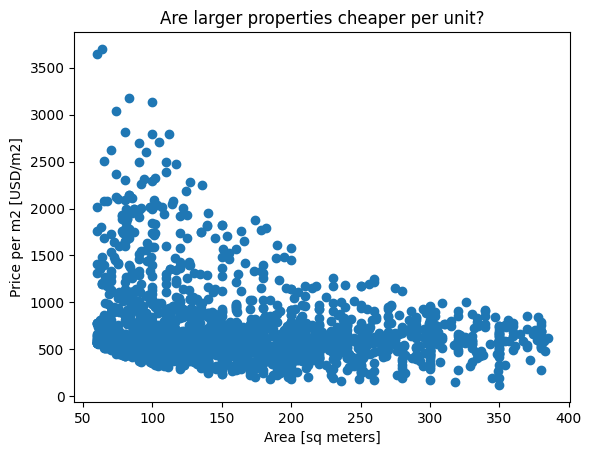

In [15]:
fig, ax = plt.subplots()

# Scatter plot
ax.scatter(x=df["area_m2"], y=df["price_per_m2"],)

ax.set_title("Are larger properties cheaper per unit?")
ax.set_xlabel("Area [sq meters]")
ax.set_ylabel("Price per m2 [USD/m2]")

plt.show()

> 📊 **Reading the `price_per_m2` scatterplot — the diminishing-returns curve**
>
> You should see a cloud of points that is **densest on the left** (small
> properties with high price-per-m²) and **sparse on the right** (large properties
> with low price-per-m²). The overall cloud slopes downward from left to right.
>
> **This pattern — high price-per-m² for small properties — has two causes:**
>
> 1. **Urban location:** Small properties are disproportionately apartments in city
>    centers where land is scarce. City-center space commands a premium per m².
>
> 2. **Fixed costs and amenities:** A building with a pool, lobby, and concierge
>    imposes a fixed cost that is distributed across fewer square meters in a small
>    apartment. The cost per m² is therefore higher.
>
> **The non-linearity challenge for Pearson r:**
>
> The Pearson correlation between `area_m2` and `price_per_m2` is likely negative
> (larger properties have lower price-per-m²) but understates the relationship
> because the relationship is curved, not linear. A non-linear measure (like
> Spearman rank correlation) would capture it better.
>
> This is a direct demonstration of Caveat 1 from §2.3: *Pearson r measures only
> linear relationships.*

# Wrap-up

Correlation quantified what visualization could only suggest. Here is what this
lesson established:

- **The Pearson correlation coefficient** (r) measures the strength and direction
  of a *linear* relationship on a scale from -1 to +1. For Mexico's housing data,
  the national area-price correlation is approximately r ≈ 0.59 — moderate to
  strong, but not tight. Quantitatively, this means area explains approximately
  35% of the variance in price (r² ≈ 0.35), leaving 65% to be explained by other
  factors. In concrete terms, a model built on area alone would produce prediction
  intervals of roughly ±$40,000 around the central estimate — useful as a rough
  guide, but far too imprecise for real pricing decisions. This is why multi-
  variable analysis, incorporating location and property type, is the necessary
  next step.

- **The correlation matrix and heatmap** revealed that area has the strongest
  correlation with price among the available numeric variables. Lat-lon correlation
  is a geographical artifact of Mexico's shape, not a market signal. Reading a
  correlation matrix systematically — diagonal check first, then strongest off-
  diagonal values, then unexpected strong correlations — prevents both missing
  important relationships and over-interpreting spurious ones. The heatmap makes
  this process visual and nearly instantaneous: strong relationships appear as
  deep colors; near-zero relationships appear as near-white. Always read the
  annotated numbers alongside the colors for precision.

- **Segmented correlations exposed enormous heterogeneity:** states range from
  r ≈ 0.0 to r ≈ 0.9+ for the same area-price relationship. The national r = 0.59
  is an average that may not describe any individual state accurately. Beware of
  aggregate statistics hiding subgroup variation. The appropriate response when
  you discover this kind of heterogeneity is not to choose one level of analysis
  — it is to report both, identify the confounding variable (in our case, location),
  verify subgroup sample sizes before interpreting subgroup results, and consider
  whether a stratified or interaction-term model is more appropriate than a single
  global model.

- **Simpson's Paradox warning:** always examine subgroup statistics alongside
  aggregate ones. A global trend can reverse, attenuate, or amplify at the subgroup
  level if the subgroup compositions differ systematically. In our housing data,
  the national r = 0.59 attenuates the strong local correlations (0.8+) seen in
  rural states, because it averages them with the near-zero correlations in urban
  markets where price is driven by neighborhood rather than floor space. Knowing
  how to detect and diagnose Simpson's Paradox is one of the most practically
  valuable skills in applied data science — it prevents exactly the kind of
  misleading policy recommendations that arise from relying on aggregate statistics.

- **Feature engineering** (`price_per_m2`) created a normalized metric that
  isolates the "density" of value. The diminishing-returns scatterplot shows that
  Pearson r understates the curved relationship between area and value-per-m² —
  a reminder that r is a linear-only tool. Feature engineering is not a trick —
  it is the process of encoding domain knowledge into the data. A domain expert
  in real estate knows intuitively that price per square meter is a better measure
  of location value than total price, which is confounded by size. Translating that
  knowledge into a new column before analysis is what separates a technically
  competent data scientist from one who deeply understands the domain they are
  working in.

> ⚠️ **Three limits of correlation analysis this lesson demonstrated:**
> (1) r assumes linearity — the curved relationship between area and price-per-m²
> was understated; (2) r ignores causation — the area-price correlation may partly
> reflect location sorting rather than a pure size effect; (3) r is distorted by
> small samples — near-perfect correlations in states with 5 listings are artifacts,
> not real patterns. All three will matter in Lesson 4's grouped analysis, and all
> three are reasons why correlation is the beginning of analysis, not the end.

➡️ **In Lesson 4 (Price per m² and Location Effects)**, we use `price_per_m2`
as the primary metric to formally decompose how much of the price variation is
explained by location versus other factors — delivering the final data-driven
answer to our research question. The segmented correlations from this lesson
provide the quantitative foundation: we already know that size explains price
differently in different states. Lesson 4 will determine whether, after
controlling for size via `price_per_m2`, location is the dominant remaining
signal — and by how much.
